# DATA2001 Assignment 2 (Weight: 25%)


The aim of this assignment is to gain practical experience in analysing unstructured data. 
You should only submit your completed Jupyter notebook in .ipynb format via Blackboard, including written answers in markdown and results from executed code cells.


The assignment comprises 5 main tasks: Data Exploration, Data Preprocessing, Model Training, Model Evaluation, and Model Analysis. You will analyze and compare two different representations, Bag of Words (BOW) and Term Frequency-Inverse Document Frequency (TF-IDF). Additionally, you will address and compare two tasks: sentiment analysis and rating prediction.


The dataset you will work with in this assignment comprises text reviews about various hotels, extracted from Tripadvisor, along with their corresponding ratings.


## Task 1: Data Exploration





1. Load the dataset from the file "hotel_reviews.csv". How many records does the dataset contain? How many distinct classes are there in the dataset?


In [1]:
import pandas as pd
import warnings
import numpy as np
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset from the file "hotel_reviews.csv".
# Load the dataset into a Pandas DataFrame
df = pd.read_csv("hotel_reviews.csv")

# How many records does the dataset contain?
# Count the number of records
num_records = df.shape[0]
print(f"The dataset contains {num_records} records.")

# How many distinct classes are there in the dataset?
# Count the number of distinct classes in the "Rating" column
num_classes = df['Rating'].nunique()
print(f"There are {num_classes} distinct classes in the dataset.")

The dataset contains 20491 records.
There are 5 distinct classes in the dataset.


2. Determine the top 10 most frequently used words in the dataset. To support your answer, create a bar plot where the x-axis represents words, and the y-axis represents the frequency of each word appearing in the entire dataset.


In [3]:
from collections import Counter
import matplotlib.pyplot as plt

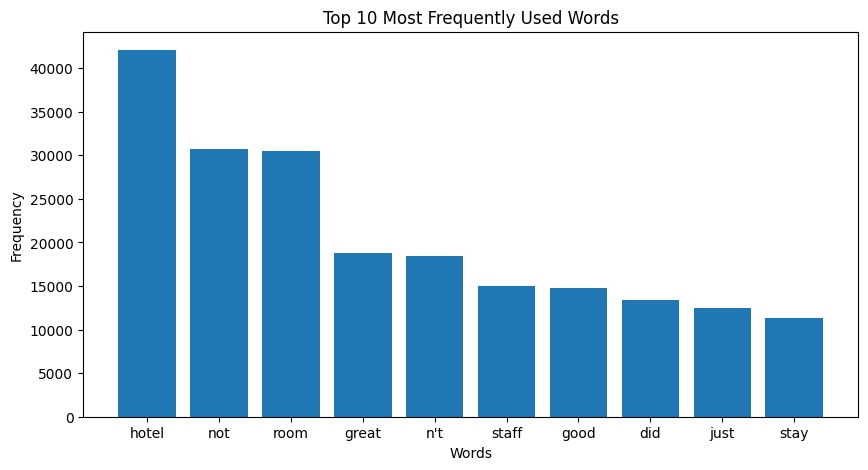

In [4]:
# Combine all the reviews into a single string
all_reviews = ' '.join(df['Review'])

# Convert to lower case and split the string into words
words = all_reviews.lower().split()

# Count the frequency of each word
word_counts = Counter(words)

# Find the 10 most common words
most_common_words = word_counts.most_common(10)

# Separate the words and their counts into two lists
words, counts = zip(*most_common_words)

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequently Used Words')
plt.show()



3. Among the top 10 most frequently used words, identify if there are any stop words included. If we exclude the stop words, would the top 10 most frequent words change? Create another bar plot similar to Question 2, but this time with the stop words removed to illustrate the updated top 10 most frequent words.

In [5]:
pip install nltk


[notice] A new release of pip is available: 23.1.2 -> 23.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1002)>
[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1002)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1002)>


False

In [7]:
from collections import Counter
import matplotlib.pyplot as plt

# Load stop words
stop_words = set(stopwords.words('english'))

# Combine all the reviews into a single string
all_reviews = ' '.join(df['Review'])

# Convert to lower case and split the string into words
words = all_reviews.lower().split()

# Filter out the stop words
filtered_words = [word for word in words if word not in stop_words]

# Count the frequency of each word
word_counts = Counter(filtered_words)

# Find the 10 most common words
most_common_words = word_counts.most_common(10)

# Separate the words and their counts into two lists
words, counts = zip(*most_common_words)

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequently Used Words (Stop Words Removed)')
plt.show()

LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - '/Users/xianglongronaldolin/nltk_data'
    - '/Library/Frameworks/Python.framework/Versions/3.11/nltk_data'
    - '/Library/Frameworks/Python.framework/Versions/3.11/share/nltk_data'
    - '/Library/Frameworks/Python.framework/Versions/3.11/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


## Task 2: Data Preprocessing

- Use the provided "clean_data" function to remove unnecessary symbols and clean the dataset.



In [ ]:
import re

def clean_data(text):
    
    # Format words and remove unwanted characters
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text) 
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'br', ' ', text)
    text = re.sub(r'\'', ' ', text)
    

    return text

In [ ]:
# 1. First, load the dataset
df = pd.read_csv("hotel_reviews.csv")

# 2. Apply the `clean_data` function to clean the "Review" column
df['Cleaned_Review'] = df['Review'].apply(clean_data)

# Now, the `Cleaned_Review` column contains the cleaned reviews.

- Split the clean dataset into separate train and test sets. For this, use the "Review" field as the feature vector (X) and the "Rating" field as the label vector (Y).

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Load the dataset
df = pd.read_csv("hotel_reviews.csv")

# Assume you've cleaned the 'Review' column and stored it in 'Cleaned_Review'
df['Cleaned_Review'] = df['Review'].apply(clean_data)  # Using the clean_data function you defined earlier

# Separate the feature vectors and labels
X = df['Cleaned_Review']
Y = df['Rating']

# Split the data into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

- Create an additional binary label by assigning ‘1’ – positive for the product ratings 4 and 5; and "–1" for product ratings 1, 2 and 3. Store it in y_train_binary and y_test_binary. 

*Tip: you can use a function copy.deepcopy for creating a copy of label variables*

In [ ]:
import copy

In [ ]:
# Define a function to convert ratings into binary labels.
def convert_to_binary(rating):
    # If rating is 4 or 5, return 1 (indicating positive).
    if rating >= 4:
        return 1
    # If rating is 1, 2, or 3, return -1 (indicating negative).
    else:
        return -1

# Apply the convert_to_binary function to the 'Y_train' pandas Series.
# This will create a new Series where each original rating is replaced with a binary label.
y_train_binary = Y_train.apply(convert_to_binary)

# Apply the convert_to_binary function to the 'Y_test' pandas Series.
# This will create a new Series where each original rating is replaced with a binary label.
y_test_binary = Y_test.apply(convert_to_binary)

# Create deep copies of 'Y_train' and 'Y_test' and apply the convert_to_binary function.
# This ensures that the original Series remain unmodified, useful if you need to use them later.
y_train_binary = copy.deepcopy(Y_train).apply(convert_to_binary)
y_test_binary = copy.deepcopy(Y_test).apply(convert_to_binary)


- Transform the cleaned data into a numerical representation using Bag of Words (BoW) and remove any stop words. Save the BoW representation in the variables train_data_BOW and test_data_BOW.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

- Create another numerical representation of the text using Term Frequency-Inverse Document Frequency (TfIdf) and remove the stop words. Save the TfIdf representation in the variables train_data_tfidf and test_data_tfidf.

In [ ]:
# Data Cleaning
X_train_cleaned = X_train.apply(clean_data)  # Assume clean_data is your data cleaning function
X_test_cleaned = X_test.apply(clean_data)

# TfIdf Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
train_data_tfidf = tfidf_vectorizer.fit_transform(X_train_cleaned)
test_data_tfidf = tfidf_vectorizer.transform(X_test_cleaned)

## Task 3: Model Training

Define 3 Logistic Regression models: *model1, model2* and *model3* and train the models as follows:
- Train the first Linear Regression model using the Bag of Words representation (train_data_BOW) to predict the hotel rating (Y).

- Train the second Linear Regression model using the TfIdf representation (train_data_tfidf) to predict the hotel rating (Y).

- Train the third Linear Regression model using the TfIdf representation (train_data_tfidf) to predict the binary sentiment label (Y_binary). 

- Make and store predictions on appropriate test sets (X_test_BOW for model1 and X_test_tfidf for model2 and model3)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Provide your answers here



## Task 4: Model Evaluation

- Compute and compare the test accuracy of Model 1 (Linear Regression with BoW representation) and Model 2 (Linear Regression with TfIdf representation). Based on your results, determine which embedding method yields higher performance in predicting the hotel ratings (Y).

In [ ]:
from sklearn.metrics import accuracy_score

# Provide your answers here


- Compute and compare the test accuracy of Model 2 and Model 3. Based on your results, analyze which task is easier: binary sentiment prediction or multi-class rating prediction.

In [ ]:
# Provide your answers here




- For Model 2,  compute additional evaluaton measures, namely confusion matrix, precision and recall.  

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Provide your answers here


## Task 5: Model Analysis



- Based on the confusion matrix obtained in the previous question (referring to Model 2, the Linear Regression with TfIdf representation for rating prediction), identify and state the number of samples that were classified to have the rating of 5 (the highest rating), but in reality, they had an actual rating of 1 (the lowest rating).

**Provide your answer here**


- Discuss the importance of considering alternative evaluation measures, such as precision and recall, instead of relying solely on accuracy. Based on this discussion, identify the most suitable evaluation metric for Model 2.

**Provide your answer here**



- For binary sentiment prediction (Model 3), visualize important words with their model coefficients.  

*Tip: you can reuse the function plot_coefficients from prac. session.*

In [ ]:
# Provide your answers here
